In [94]:
# regression dataset 

# no null -> 1 dup -> removed
# Boxplot -> bmi, charges -> outliers 

In [95]:
import pandas as pd

In [96]:
df = pd.read_csv('/Users/sudharsank/datasets/insurance.csv')

In [97]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [99]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [100]:
df.duplicated().sum()

np.int64(1)

In [101]:
df.shape

(1338, 7)

In [102]:
df.drop_duplicates(inplace=True)

In [103]:
df.shape

(1337, 7)

In [104]:
df.duplicated().sum()

np.int64(0)

In [105]:
import seaborn as sns

In [106]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [107]:
df['age'].value_counts()

age
18    69
19    67
50    29
51    29
47    29
46    29
45    29
20    29
48    29
52    29
22    28
49    28
54    28
53    28
21    28
26    28
24    28
25    28
28    28
27    28
23    28
43    27
29    27
30    27
41    27
42    27
44    27
31    27
40    27
32    26
33    26
56    26
34    26
55    26
57    26
37    25
59    25
58    25
36    25
38    25
35    25
39    25
61    23
60    23
63    23
62    23
64    22
Name: count, dtype: int64

In [108]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [109]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


<Axes: xlabel='age', ylabel='Density'>

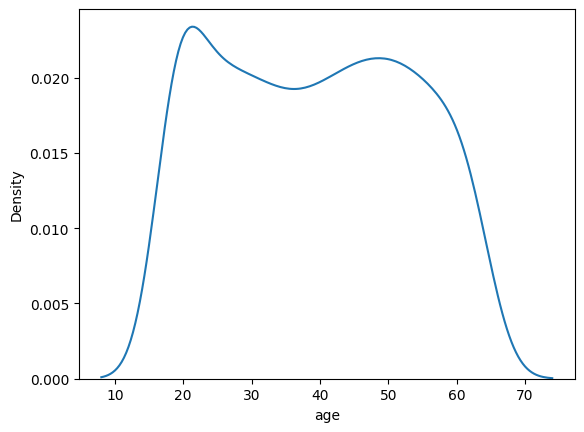

In [110]:
sns.kdeplot(df['age'])

<Axes: xlabel='bmi', ylabel='Density'>

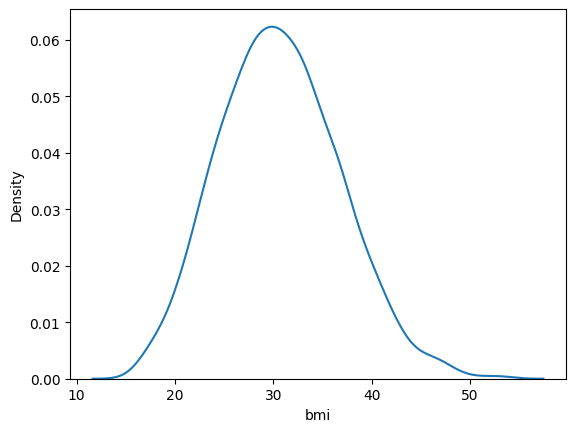

In [111]:
sns.kdeplot(df['bmi'])

<Axes: xlabel='children', ylabel='Density'>

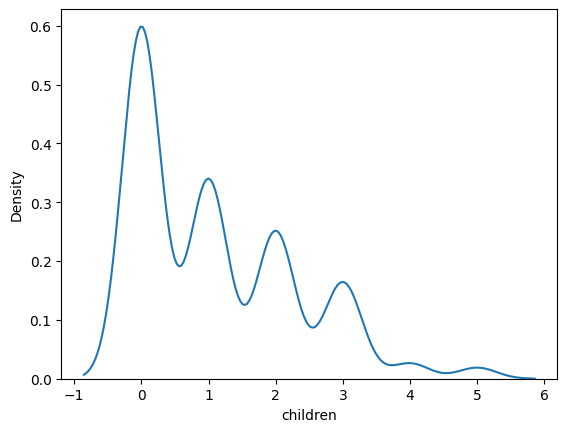

In [112]:
sns.kdeplot(df['children'])

<Axes: xlabel='charges', ylabel='Density'>

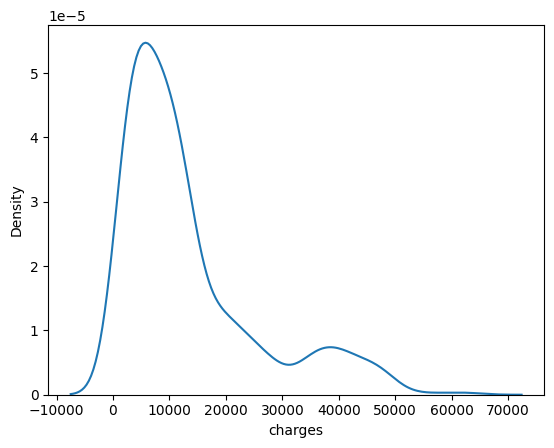

In [113]:
sns.kdeplot(df['charges'])

In [114]:
corr = df[['age', 'bmi', 'children', 'charges']].corr()

In [115]:
corr

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


<Axes: >

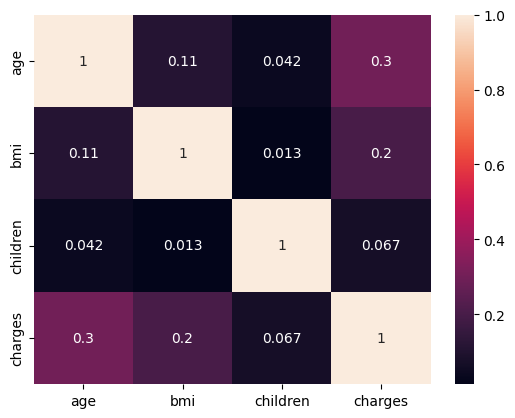

In [116]:
sns.heatmap(corr, annot=True)

In [117]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


<Axes: ylabel='age'>

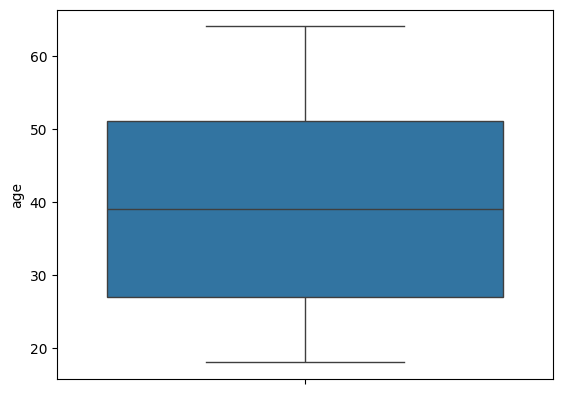

In [118]:
sns.boxplot(df['age'])

<Axes: ylabel='bmi'>

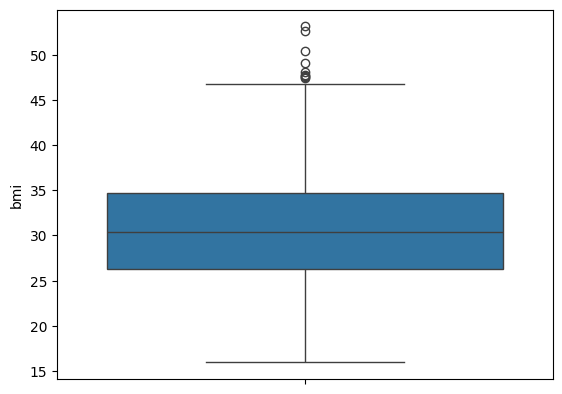

In [119]:
sns.boxplot(df['bmi'])


<Axes: ylabel='children'>

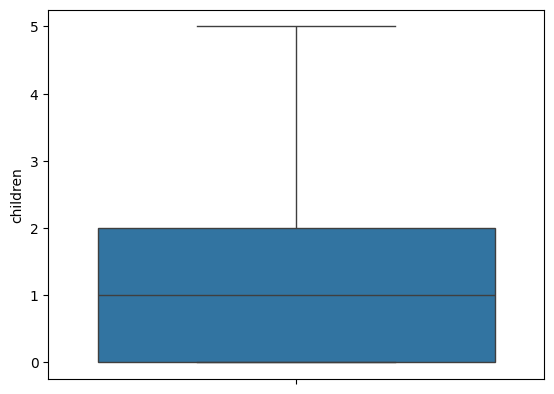

In [120]:
sns.boxplot(df['children'])

<Axes: ylabel='charges'>

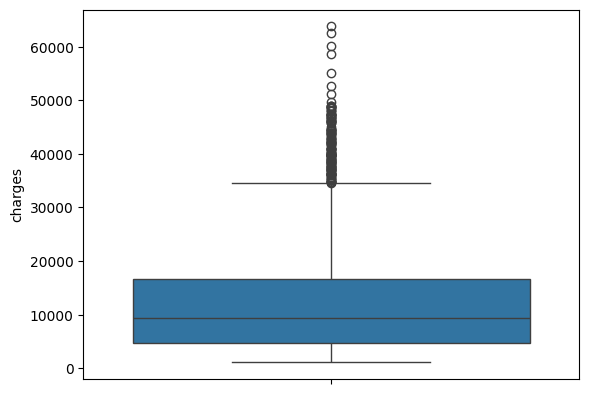

In [121]:
sns.boxplot(df['charges'])

<Axes: xlabel='children', ylabel='charges'>

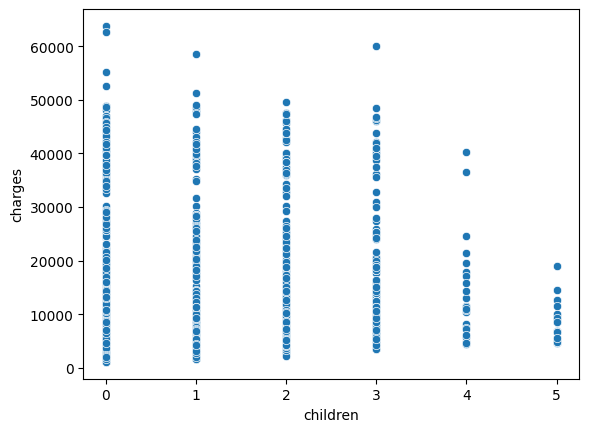

In [122]:
sns.scatterplot(x='children', y='charges', data=df)

<Axes: xlabel='age', ylabel='charges'>

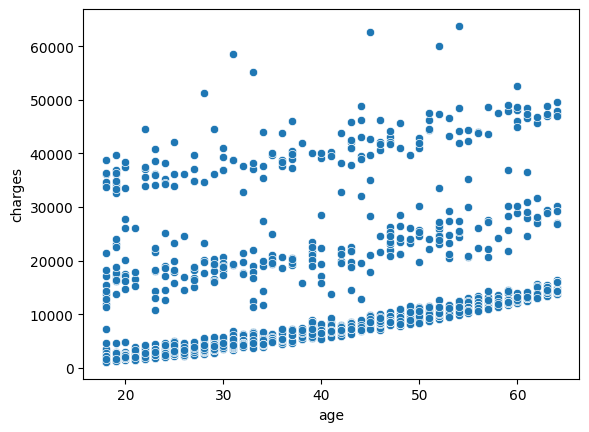

In [123]:
sns.scatterplot(x='age', y='charges', data=df)

<Axes: xlabel='bmi', ylabel='charges'>

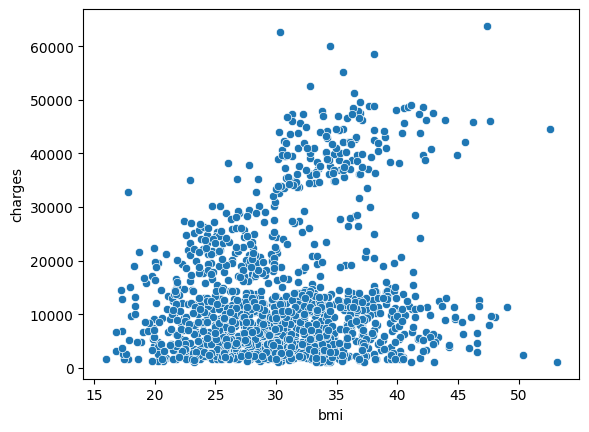

In [124]:
sns.scatterplot(x='bmi', y='charges', data=df)

<Axes: xlabel='sex', ylabel='charges'>

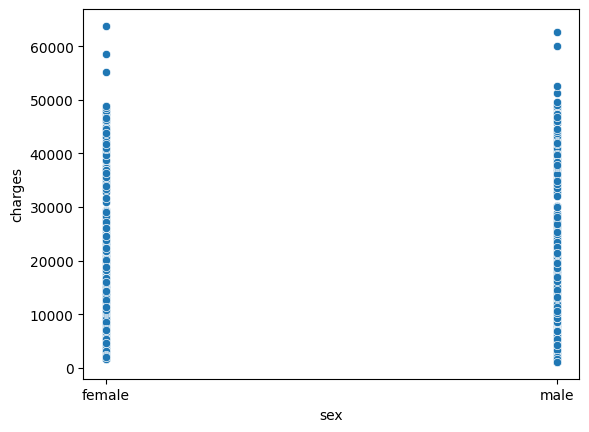

In [125]:
sns.scatterplot(x='sex', y='charges', data=df)

In [126]:
# z-score -> outliers -> bmi, charges

In [127]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['bmi']))
df_clean = (df[z_scores < 2])

print(df_clean.describe())

               age          bmi     children       charges
count  1280.000000  1280.000000  1280.000000   1280.000000
mean     39.297656    30.429746     1.088281  13270.092517
std      14.066401     5.412967     1.205611  11981.523777
min      18.000000    18.500000     0.000000   1121.873900
25%      27.000000    26.378750     0.000000   4759.514250
50%      40.000000    30.230000     1.000000   9388.753650
75%      51.000000    34.296250     2.000000  17052.776050
max      64.000000    42.750000     5.000000  62592.873090


<Axes: ylabel='bmi'>

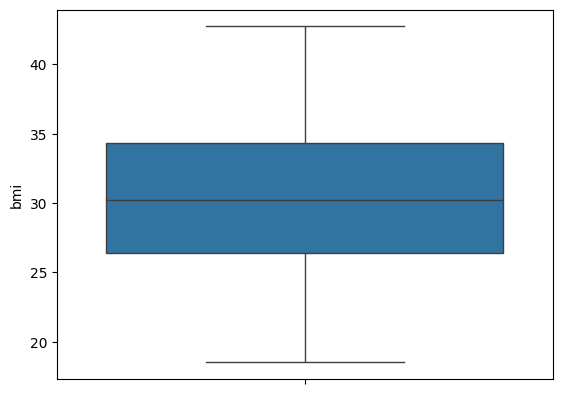

In [128]:
sns.boxplot(df_clean['bmi'])

In [129]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))


Original rows: 1337
Cleaned rows: 1280
Rows removed: 57


In [130]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['bmi']))
df_clean = (df[z_scores < 2])

print(df_clean.describe())

               age          bmi     children       charges
count  1280.000000  1280.000000  1280.000000   1280.000000
mean     39.297656    30.429746     1.088281  13270.092517
std      14.066401     5.412967     1.205611  11981.523777
min      18.000000    18.500000     0.000000   1121.873900
25%      27.000000    26.378750     0.000000   4759.514250
50%      40.000000    30.230000     1.000000   9388.753650
75%      51.000000    34.296250     2.000000  17052.776050
max      64.000000    42.750000     5.000000  62592.873090


In [131]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 1337
Cleaned rows: 1280
Rows removed: 57


In [132]:
df_clean.shape

(1280, 7)

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [134]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1280 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1280 non-null   int64  
 1   sex       1280 non-null   object 
 2   bmi       1280 non-null   float64
 3   children  1280 non-null   int64  
 4   smoker    1280 non-null   object 
 5   region    1280 non-null   object 
 6   charges   1280 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 80.0+ KB


In [135]:
# encoding

<Axes: xlabel='bmi', ylabel='Density'>

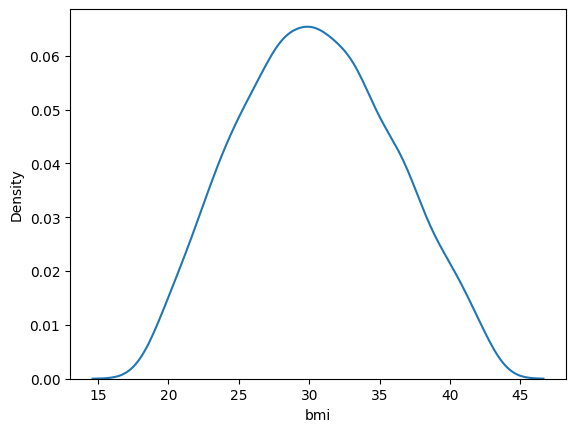

In [136]:
sns.kdeplot(df_clean['bmi'])

In [137]:
corr = df_clean[['age', 'bmi', 'children', 'charges']].corr()

In [138]:
corr

,age,bmi,children,charges
age,1.000000,0.105440,0.043124,0.304812
bmi,0.105440,1.000000,-0.003939,0.201460
children,0.043124,-0.003939,1.000000,0.068142
charges,0.304812,0.201460,0.068142,1.000000


<Axes: >

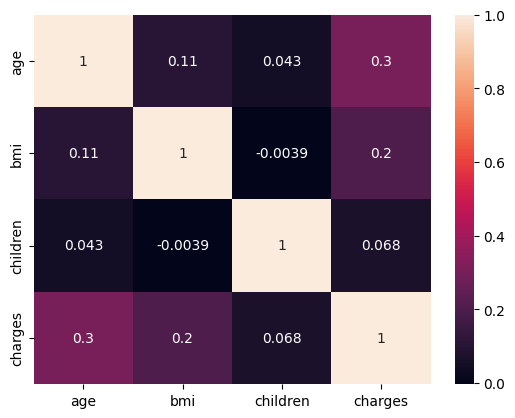

In [139]:
sns.heatmap(corr, annot=True)

In [140]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [141]:
from sklearn.preprocessing import OrdinalEncoder
o = OrdinalEncoder()
df_clean[['sex']] = o.fit_transform(df_clean[['sex']])
df_clean[['smoker']] = o.fit_transform(df_clean[['smoker']])
df_clean[['region']] = o.fit_transform(df_clean[['region']])


/var/folders/7b/5_gy8f1j7171y56xbfvy4r7h0000gn/T/ipykernel_68858/1739734939.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[['sex']] = o.fit_transform(df_clean[['sex']])
/var/folders/7b/5_gy8f1j7171y56xbfvy4r7h0000gn/T/ipykernel_68858/1739734939.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[['smoker']] = o.fit_transform(df_clean[['smoker']])
/var/folders/7b/5_gy8f1j7171y56xbfvy4r7h0000gn/T/ipykernel_68858/1739734939.py:5: SettingWithCopyWarning: 
A value is trying to be set on a 

In [142]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1280 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1280 non-null   int64  
 1   sex       1280 non-null   float64
 2   bmi       1280 non-null   float64
 3   children  1280 non-null   int64  
 4   smoker    1280 non-null   float64
 5   region    1280 non-null   float64
 6   charges   1280 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 80.0 KB


In [143]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,0.0,27.900,0,1.0,3.0,16884.92400
1,18,1.0,33.770,1,0.0,2.0,1725.55230
2,28,1.0,33.000,3,0.0,2.0,4449.46200
3,33,1.0,22.705,0,0.0,1.0,21984.47061
4,32,1.0,28.880,0,0.0,1.0,3866.85520
...,...,...,...,...,...,...,...
1333,50,1.0,30.970,3,0.0,1.0,10600.54830
1334,18,0.0,31.920,0,0.0,0.0,2205.98080
1335,18,0.0,36.850,0,0.0,2.0,1629.83350
1336,21,0.0,25.800,0,0.0,3.0,2007.94500


In [144]:
# feature scaling -> reg dataset -> StandardScaler 

In [145]:
x = df_clean.drop(columns='charges')
y = df_clean['charges']
x

,age,sex,bmi,children,smoker,region
0,19,0.0,27.900,0,1.0,3.0
1,18,1.0,33.770,1,0.0,2.0
2,28,1.0,33.000,3,0.0,2.0
3,33,1.0,22.705,0,0.0,1.0
4,32,1.0,28.880,0,0.0,1.0
...,...,...,...,...,...,...
1333,50,1.0,30.970,3,0.0,1.0
1334,18,0.0,31.920,0,0.0,0.0
1335,18,0.0,36.850,0,0.0,2.0
1336,21,0.0,25.800,0,0.0,3.0


In [146]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

sc.fit_transform(x)

array([[-1.44355259, -1.00941936, -0.46753191, -0.90303297,  1.97590854,
         1.34373241],
       [-1.51467177,  0.99066854,  0.61732492, -0.07325393, -0.5060963 ,
         0.44133079],
       [-0.80348001,  0.99066854,  0.47501832,  1.58630415, -0.5060963 ,
         0.44133079],
       ...,
       [-1.51467177, -1.00941936,  1.18655133, -0.90303297, -0.5060963 ,
         0.44133079],
       [-1.30131424, -1.00941936, -0.85564083, -0.90303297, -0.5060963 ,
         1.34373241],
       [ 1.54345281, -1.00941936, -0.2512998 , -0.90303297,  1.97590854,
        -0.46107083]], shape=(1280, 6))

In [147]:
x

,age,sex,bmi,children,smoker,region
0,19,0.0,27.900,0,1.0,3.0
1,18,1.0,33.770,1,0.0,2.0
2,28,1.0,33.000,3,0.0,2.0
3,33,1.0,22.705,0,0.0,1.0
4,32,1.0,28.880,0,0.0,1.0
...,...,...,...,...,...,...
1333,50,1.0,30.970,3,0.0,1.0
1334,18,0.0,31.920,0,0.0,0.0
1335,18,0.0,36.850,0,0.0,2.0
1336,21,0.0,25.800,0,0.0,3.0


In [148]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [149]:
# LinearRegression - training

In [150]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_train)


In [151]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_train, y_pred))
print(mean_absolute_error(y_train, y_pred))

0.7534675604331112
4180.102020121587


In [152]:
# LinearRegression - testing

In [153]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)


In [154]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.7341800145718311
4118.608302598906


In [180]:
# linear reg -> training score > testing score --> underfit

In [156]:
# random forest - train

In [157]:
from sklearn.ensemble import RandomForestRegressor
lr = RandomForestRegressor()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_train)


In [158]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_train, y_pred))
print(mean_absolute_error(y_train, y_pred))

0.9757850641124294
1026.6198444079312


In [159]:
# random forest - testing

In [186]:
from sklearn.ensemble import RandomForestRegressor
lr = RandomForestRegressor(n_estimators=5000, max_depth=3)
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)


In [187]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.8374251987252126
2759.2305322152984


In [162]:
# DecisionTree - training

In [163]:
from sklearn.tree import DecisionTreeRegressor
lr = DecisionTreeRegressor()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_train)

In [164]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_train, y_pred))
print(mean_absolute_error(y_train, y_pred))

0.9994778071166158
12.208219287109374


In [165]:
# DecisionTree - testing

In [166]:
from sklearn.tree import DecisionTreeRegressor
lr = DecisionTreeRegressor()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)


In [167]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.6992907010386711
3030.9521694140626


In [ ]:
# KNN - training

In [169]:
from sklearn.neighbors import KNeighborsRegressor
lr = KNeighborsRegressor()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_train)

In [170]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_train, y_pred))
print(mean_absolute_error(y_train, y_pred))

0.43706159052158533
6214.5032896724615


In [171]:
# KNN - testing

In [172]:
from sklearn.neighbors import KNeighborsRegressor
lr = KNeighborsRegressor()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)


In [173]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

-0.014076754461803898
8252.673690524218


In [174]:
# SVR - Training

In [175]:
from sklearn.svm import SVR
lr = SVR()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_train)

In [176]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_train, y_pred))
print(mean_absolute_error(y_train, y_pred))

-0.10658892869790382
8402.569453862667


In [177]:
# SVR - Testing

In [178]:
from sklearn.svm import SVR
lr = SVR()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

In [179]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

-0.1363459632559334
7783.121666779858
